In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("path of dataset")

In [3]:
df['InvoiceDate']

0          12/1/2010 8:26
1          12/1/2010 8:26
2          12/1/2010 8:26
3          12/1/2010 8:26
4          12/1/2010 8:26
               ...       
541904    12/9/2011 12:50
541905    12/9/2011 12:50
541906    12/9/2011 12:50
541907    12/9/2011 12:50
541908    12/9/2011 12:50
Name: InvoiceDate, Length: 541909, dtype: str

In [4]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB


In [6]:
df = df.dropna(subset=['CustomerID'])

In [7]:
df = df.dropna(subset=['Description'])

In [8]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [9]:
df = df[df['Quantity'] > 0]

In [10]:
df = df[df['UnitPrice'] > 0]

In [11]:
df = df.drop_duplicates()

In [12]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  str           
 1   StockCode    392692 non-null  str           
 2   Description  392692 non-null  str           
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  str           
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 30.0 MB


In [14]:




df.to_csv('cleaned_retail.csv', index=False)

In [15]:

df = pd.read_csv("cleaned_retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [16]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

## Top 10 Countries by Revenue

In [17]:
country_revenue = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

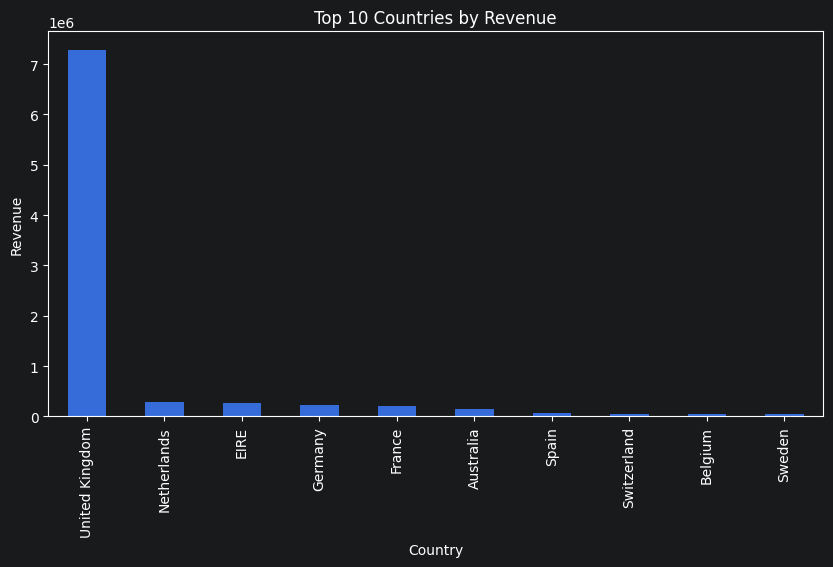

In [18]:
country_revenue.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.show()

## Top Products

In [19]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)

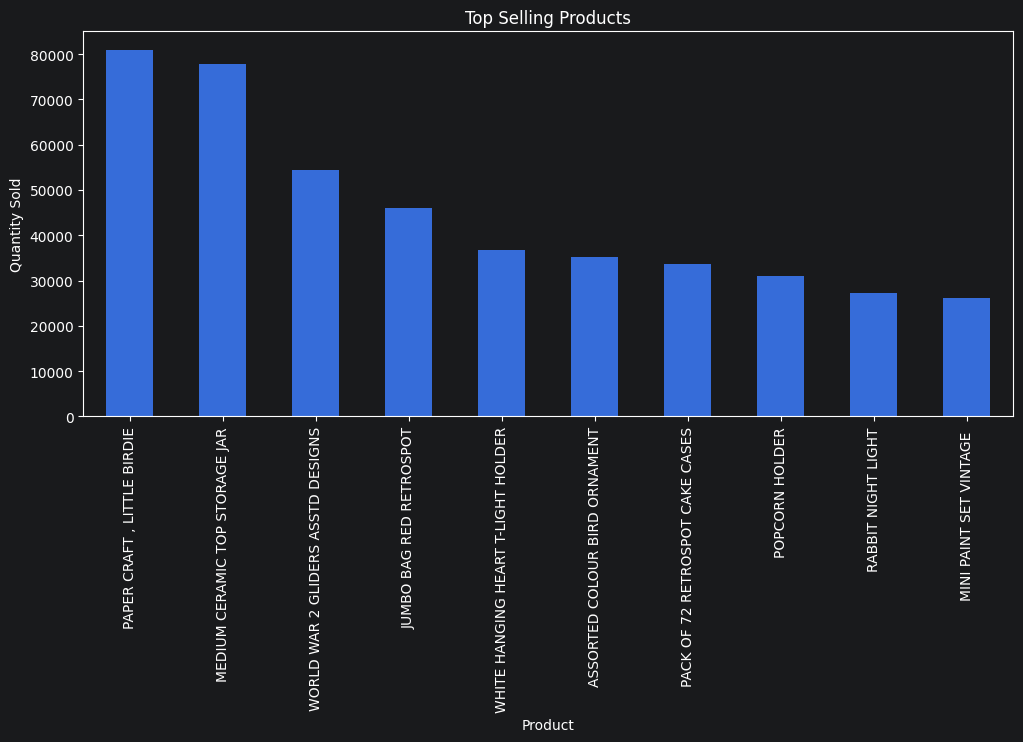

In [20]:
top_products.head(10).plot(kind='bar', figsize=(12,5))

plt.title("Top Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.show()

## Monthly Revenue Trend

In [21]:
df['Month'] = df['InvoiceDate'].dt.strftime('%Y-%m')

In [22]:
monthly_revenue = df.groupby('Month')['TotalPrice'].sum()

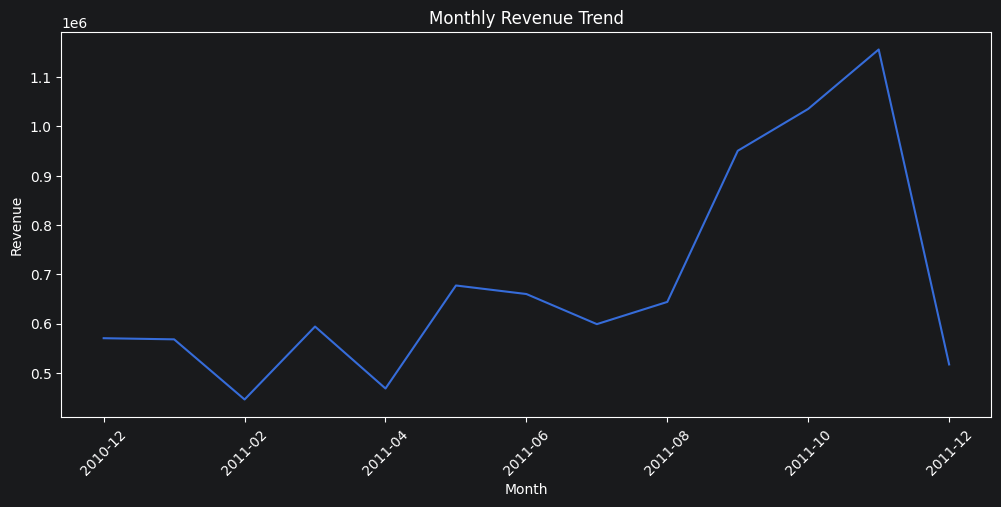

In [23]:
monthly_revenue.plot(figsize=(12,5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [24]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(reference_date)

2011-12-10 12:50:00


In [25]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

In [26]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [27]:
rfm.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [28]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


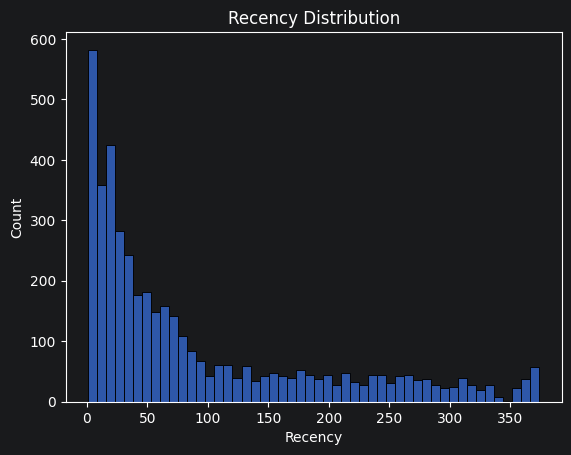

In [29]:
sns.histplot(rfm['Recency'], bins=50)

plt.title("Recency Distribution")

plt.show()

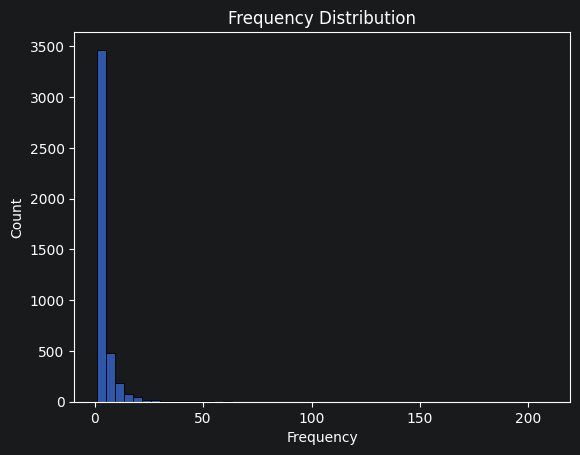

In [30]:
sns.histplot(rfm['Frequency'], bins=50)

plt.title("Frequency Distribution")

plt.show()

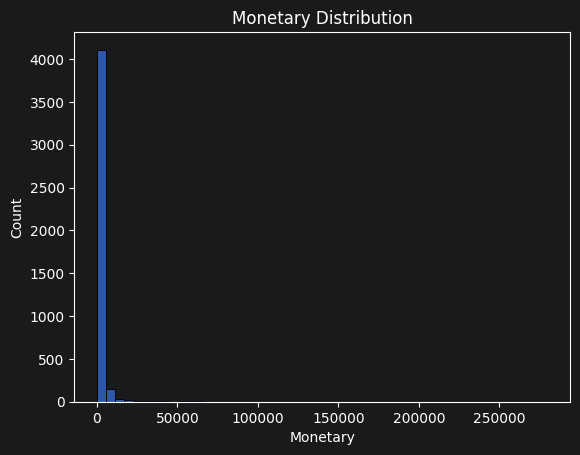

In [31]:
sns.histplot(rfm['Monetary'], bins=50)

plt.title("Monetary Distribution")

plt.show()

In [32]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])

In [33]:
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])

In [34]:
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

In [35]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

In [36]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


In [37]:
def customer_segment(row):

    if row['R_Score'] >= 3 and row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'VIP Customers'

    elif row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'Loyal Customers'

    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk Customers'

    else:
        return 'Regular Customers'

In [38]:
rfm['Segment'] = rfm.apply(customer_segment, axis=1)

In [39]:
rfm['Segment'].value_counts()

Segment
Regular Customers    2375
VIP Customers        1317
Loyal Customers       449
At Risk Customers     197
Name: count, dtype: int64

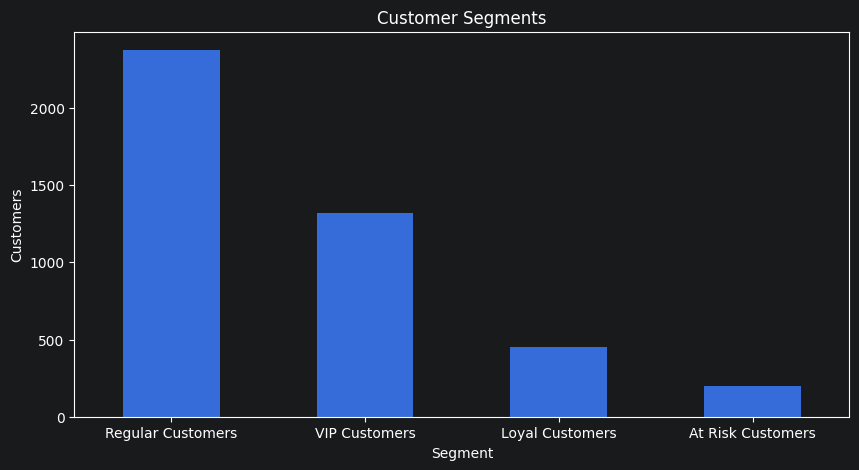

In [40]:
segment_counts = rfm['Segment'].value_counts()

segment_counts.plot(kind='bar', figsize=(10,5))

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Customers")

plt.xticks(rotation=0)

plt.show()

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [42]:
rfm_ml = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_ml)
inertia = []

for k in range(1,11):

    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

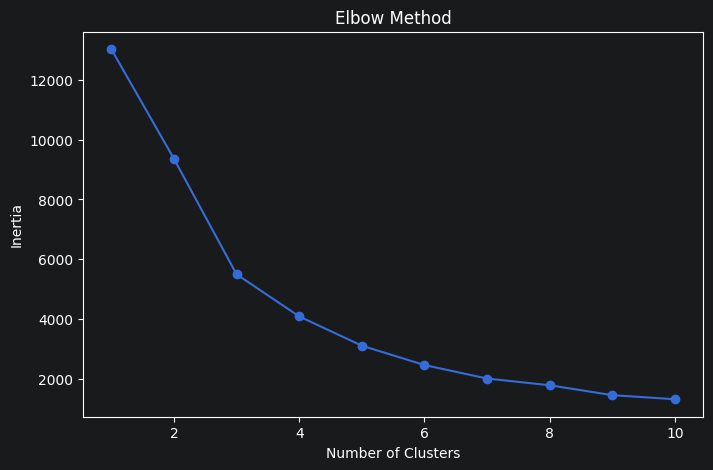

In [43]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

In [44]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm['Cluster'].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

In [45]:
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

print(cluster_summary)

            Recency  Frequency       Monetary
Cluster                                      
0         43.702685   3.682711    1353.625312
1        248.075914   1.552015     478.848773
2          7.384615  82.538462  127187.959231
3         15.500000  22.333333   12690.500392


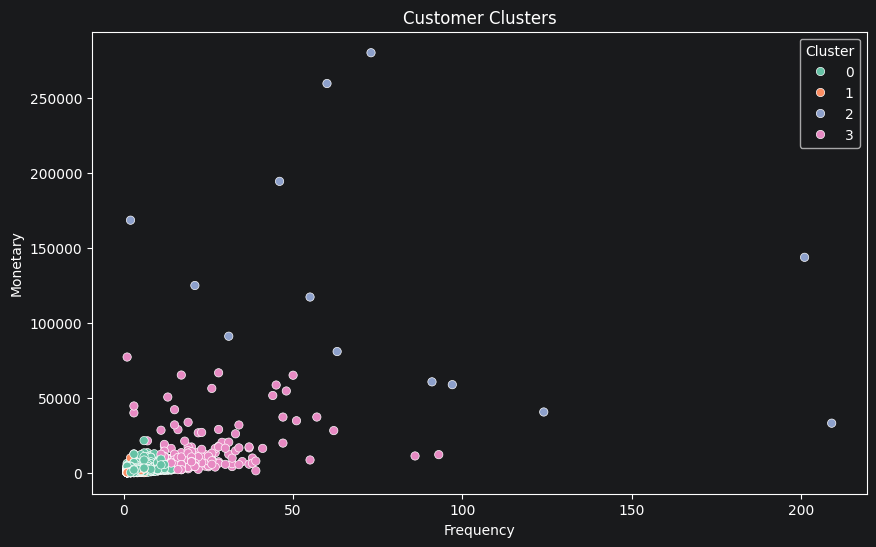

In [46]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=rfm['Frequency'],
    y=rfm['Monetary'],
    hue=rfm['Cluster'],
    palette='Set2'
)

plt.title("Customer Clusters")

plt.show()

In [47]:
rfm_log = rfm[['Recency','Frequency','Monetary']].copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

In [48]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

In [49]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

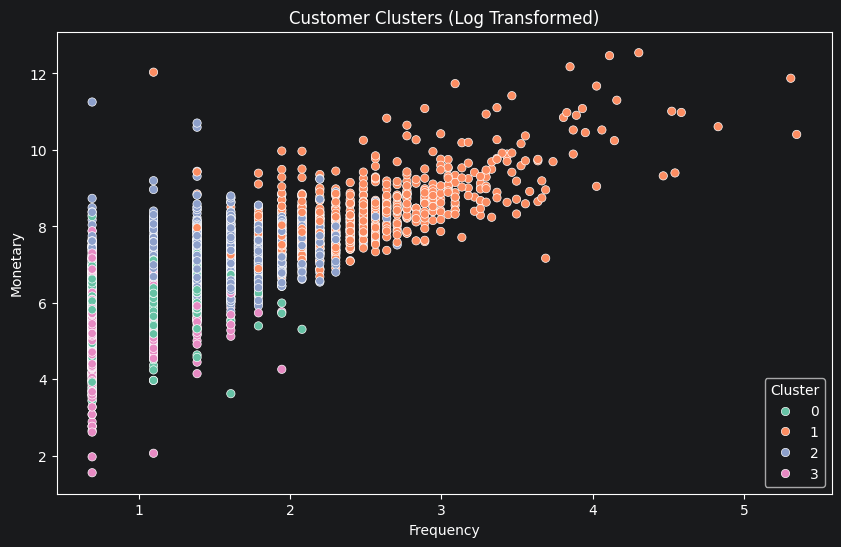

In [50]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=rfm_log['Frequency'],
    y=rfm_log['Monetary'],
    hue=rfm['Cluster'],
    palette='Set2'
)

plt.title("Customer Clusters (Log Transformed)")

plt.show()

In [51]:
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

print(cluster_summary)

            Recency  Frequency     Monetary
Cluster                                    
0         20.047897   2.008178   510.281472
1         11.736917  13.775106  8107.548571
2         66.718987   4.172996  1819.250247
3        186.730818   1.338994   353.811051


In [52]:
cluster_labels = {
    0: 'Regular Customers',
    1: 'VIP Customers',
    2: 'Loyal Customers',
    3: 'At Risk Customers'
}

rfm['ClusterLabel'] = rfm['Cluster'].map(cluster_labels)

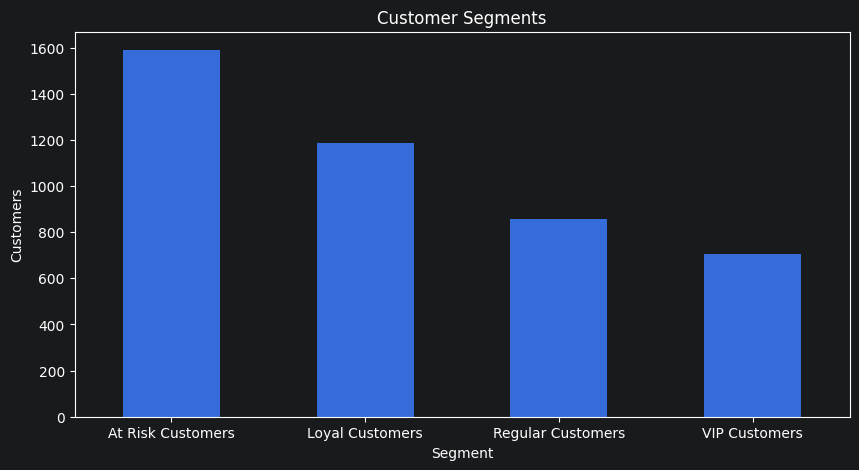

In [53]:
rfm['ClusterLabel'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Customers")

plt.xticks(rotation=0)

plt.show()

In [54]:
final_df = df.merge(
    rfm[['Recency','Frequency','Monetary',
         'Cluster','ClusterLabel']],
    on='CustomerID',
    how='left'
)


In [55]:
final_df.to_csv(
    "path of dataset",
    index=False
)

In [57]:
rfm

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Cluster,ClusterLabel
CustomerID,,,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,Regular Customers,2,Loyal Customers
12347.0,2,7,4310.00,4,4,4,444,VIP Customers,1,VIP Customers
12348.0,75,4,1797.24,2,3,4,234,Loyal Customers,2,Loyal Customers
12349.0,19,1,1757.55,3,1,4,314,Regular Customers,0,Regular Customers
12350.0,310,1,334.40,1,1,2,112,Regular Customers,3,At Risk Customers
...,...,...,...,...,...,...,...,...,...,...
18280.0,278,1,180.60,1,2,1,121,Regular Customers,3,At Risk Customers
18281.0,181,1,80.82,1,2,1,121,Regular Customers,3,At Risk Customers
18282.0,8,2,178.05,4,3,1,431,Regular Customers,0,Regular Customers


In [58]:
rfm.to_csv(
    r"path of dataset"
)